# Paper Figures

In [1]:
import os
import matplotlib.pyplot as plt
from matplotlib import colormaps
from src.models.NSI import NSI
from src.models.channel import *
from src.models.continuous_models import *
from tqdm.notebook import tqdm
import pickle
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from scipy import stats
from scipy.interpolate import interp1d
from collections import defaultdict
import numpy as np
import numpy.typing as npt
import networkx as nx
import matplotlib
import seaborn as sns
from collections.abc import Callable
from scipy.optimize import minimize, curve_fit

## Constants

In [2]:
COLORS = ['crimson', 'steelblue', 'goldenrod', 'mediumseagreen']

## Functions

In [54]:
def simulate(num_runs: int,
             channel: np.ndarray,
             N: int,
             initial_state: np.ndarray,
             beta: float, 
             k: int,
             max_time: int
            ):

    """
    runs: Number of runs 
    channel: Q as a numpy array
    N: population size 
    initial_state: initial INTEGER NUMBER of people with each message at time T=0
    beta: transmissibility 
    k: average number of contacts
    max_time: max simulation time 
    """
        
    alphabet_size = channel.shape[0]

    # Noisy Gillespie Algorithm
    runs = list()
    for _ in tqdm(range(num_runs)):
        
        sim = NoisyGillespie(N=N, initial_state=initial_state, beta=beta, k=k, 
                            channel=channel)
        sim_output = sim.simulate(max_time=max_time, density=True)
        runs.append((sim_output[0], sim_output[1]))
                                 
    # Interpolating Gillespie Means
    common_time = np.linspace(0, max_time, max_time+1)
    interpolated_values = []
    
    for run_t, run_y in runs:
        interp_func = interp1d(run_t, run_y, kind='linear', fill_value='extrapolate', axis=0) 
        interpolated_values.append(interp_func(common_time))
    
    interp_sim_arr = np.array(interpolated_values)

    sim_means = np.mean(interp_sim_arr, axis=0)
    sim_se = np.std(interp_sim_arr, axis=0) / np.sqrt(num_runs)
    conf_int = 1.96 * sim_se

    sim_lower = sim_means - conf_int
    sim_higher = sim_means + conf_int

    sim_lower = np.clip(sim_lower, 0, 1)
    sim_higher = np.clip(sim_higher, 0, 1)

    mean_gillespie_results = (common_time, sim_means)
    gillespie_ci = (sim_lower, sim_higher)

    return mean_gillespie_results, gillespie_ci

In [4]:
def well_mixed_mean_field(channel: np.ndarray,
                          N: int,
                          initial_state: np.ndarray,
                          beta: float, 
                          k: int,
                          max_time: int,
                          common_time: np.ndarray
                         ):

    """
    runs: Number of runs 
    channel: Q as a numpy array
    N: population size 
    initial_state: initial DENSITY of people with each message at time T=0
    beta: transmissibility 
    k: average number of contacts
    max_time: max simulation time 
    common_time: output[0][0] from simulate() or any other range of values to draw points 
    """
    
    mean_field = ODE(beta=beta, k=k, channel=channel, T=max_time, t_eval=common_time)
    analytic_curve = mean_field(initial_state=initial_state)
    mean_field_results = (analytic_curve.t, analytic_curve.y.T)
    return mean_field_results

In [5]:
def plot_simulation(sim_output,
                    alpha: float = 0.3, 
                    colors: list = COLORS,
                    mean_field: None | tuple = None
                   ):

    results, cis = sim_output
    common_time, x = results
    sim_lower, sim_higher = cis
    for dim in range(x.shape[1]):
        plt.plot(common_time, x[:, dim], color=colors[dim])
        plt.fill_between(common_time, x[:, dim], sim_lower[:, dim], 
                                                 alpha=0.6, color=colors[dim])
        plt.fill_between(common_time, x[:, dim], sim_higher[:, dim], 
                                                 alpha=0.6, color=colors[dim])
        if mean_field is not None:
            plt.plot(mean_field[0], mean_field[1], linestyle='dotted', alpha=0.6, 
                                            color='black', markersize=4)

In [13]:
test = simulate(num_runs=10, 
                channel=single_flip_channel(1, 0.1), 
                N=100,
                initial_state=np.array([1, 0]),
                beta=0.05,
                k=4,
                max_time=100
               )

  0%|          | 0/10 [00:00<?, ?it/s]

In [14]:
test_mf = well_mixed_mean_field(channel=single_flip_channel(1, 0.1), 
                                N=100,
                                initial_state=np.array([1/100, 0]),
                                beta=0.05,
                                k=4,
                                max_time=100, 
                                common_time=test[0][0]
                               )

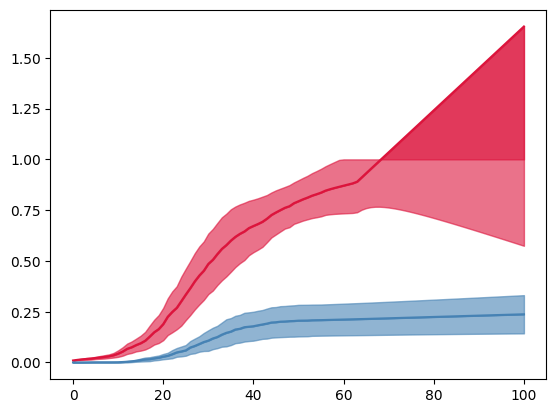

In [15]:
plot_simulation(test)

## Figure 1: Single-Error Time Dynamics
Binary symmetric channel at a single error value.
Solid lines = simulation mean ± 95% CI (shaded); dashed lines = mean field.

  0%|          | 0/1000 [00:00<?, ?it/s]

/tmp/ipykernel_3875501/697020707.py:36: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(ncol=2, fontsize=8)


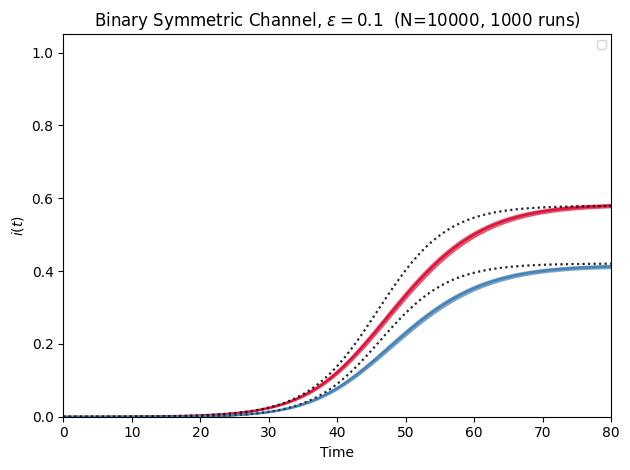

In [74]:
epsilon = 0.1
channel = single_flip_channel(1, epsilon)   # 2x2 binary symmetric
num_runs = 1000 
N = 10000
initial_state = np.array([1, 0])
beta = 0.05
k = 4
max_time = 80


binsym01_sim = simulate(num_runs=num_runs,
                        channel=channel,
                        N=N,
                        initial_state=initial_state,
                        beta=beta,
                        k=k,
                        max_time=max_time
                       )

binsym01_mf = well_mixed_mean_field(channel=channel,
                                    N=N,
                                    initial_state=initial_state/N,
                                    beta=beta,
                                    k=k,
                                    max_time=max_time,
                                    common_time=binsym01_sim[0][0]
                                   )

plot_simulation(binsym01_sim, mean_field=binsym01_mf)

plt.xlabel('Time')
plt.ylabel(r'$i(t)$')
plt.title(fr'Binary Symmetric Channel, $\varepsilon = {epsilon}$  (N={N}, {num_runs} runs)')
plt.ylim(0, 1.05)
plt.xlim(0, max_time)
plt.legend(ncol=2, fontsize=8)
plt.tight_layout()
#plt.savefig('/home/sagar/modeling-info-spread/reports/figures/PRE_figs/well_mixed_fit_01.pdf')
plt.show()

  0%|          | 0/1000 [00:00<?, ?it/s]

/tmp/ipykernel_3875501/3144681713.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(ncol=2, fontsize=8)


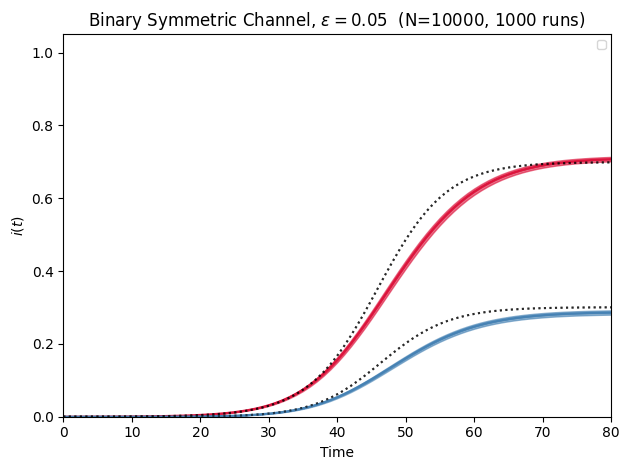

In [75]:
epsilon = 0.05
channel = single_flip_channel(1, epsilon)   # 2x2 binary symmetric


binsym001_sim = simulate(num_runs=num_runs,
                        channel=channel,
                        N=N,
                        initial_state=initial_state,
                        beta=beta,
                        k=k,
                        max_time=max_time
                       )

binsym001_mf = well_mixed_mean_field(channel=channel,
                                    N=N,
                                    initial_state=initial_state/N,
                                    beta=beta,
                                    k=k,
                                    max_time=max_time,
                                    common_time=binsym01_sim[0][0]
                                   )

plot_simulation(binsym001_sim, mean_field=binsym001_mf)

plt.xlabel('Time')
plt.ylabel(r'$i(t)$')
plt.title(fr'Binary Symmetric Channel, $\varepsilon = {epsilon}$  (N={N}, {num_runs} runs)')
plt.ylim(0, 1.05)
plt.xlim(0, max_time)
plt.legend(ncol=2, fontsize=8)
plt.tight_layout()
#plt.savefig('/home/sagar/modeling-info-spread/reports/figures/PRE_figs/well_mixed_fit_001.pdf')
plt.show()

## Figure 2: Trajectory with varying $i_0$

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

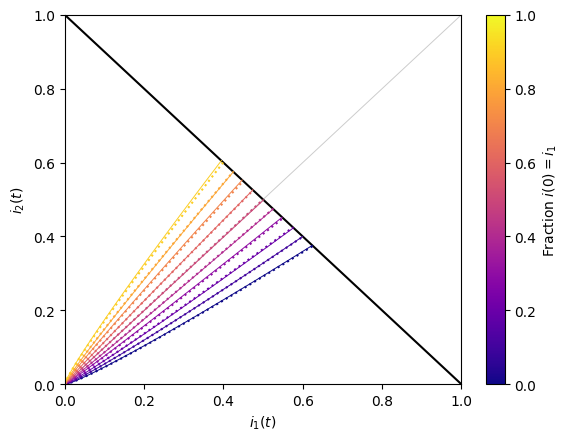

In [80]:
fig, axs = plt.subplots()

colormap = plt.cm.plasma # set colormap

i0 = 10
epsilon = 0.1
channel = single_flip_channel(1, epsilon)   # 2x2 binary symmetric
num_runs = 1000 
N = 10000
beta = 0.05
k = 4
max_time = 80


# Surface
plt.plot([x for x in np.linspace(0, 1, 100)], [1 - x for x in np.linspace(0,1,100)], 'k')

# Halfway Line
plt.plot([x for x in np.linspace(0, 1, 100)], [x for x in np.linspace(0,1,100)], 'grey', alpha=0.4, linewidth=0.7)
    
for i in range(i0):
    
    i01 = i0 - i
    i02 = i
        
        
    i0_initial_state = np.array([i01,i02])

    # Simulation
    i0_sim = simulate(num_runs=num_runs,
                      channel=channel,
                      N=N,
                      initial_state=i0_initial_state,
                      beta=beta,
                      k=k,
                      max_time=max_time
                     )
    
    i0_mean_field = well_mixed_mean_field(channel=channel,
                                          N=N,
                                          initial_state=i0_initial_state/N,
                                          beta=beta,
                                          k=k,
                                          max_time=max_time,
                                          common_time=i0_sim[0][0]
                                         )
    

    plt.plot(i0_mean_field[1][:, 0], i0_mean_field[1][:, 1], linestyle='dotted', color=colormap(i/i0))
    plt.plot(i0_sim[0][1][:, 0], i0_sim[0][1][:, 1], color=colormap(i/i0), linewidth=0.7)
    

plt.ylim(0,1)
plt.xlim(0,1)

plt.ylabel(r'$i_2(t)$')
plt.xlabel(r'$i_1(t)$')

    
# setup the colorbar
normalize = mcolors.Normalize(vmin=0, vmax=1)
scalarmappaple = plt.cm.ScalarMappable(norm=normalize, cmap=colormap)
scalarmappaple.set_array([i/100 for i in range(100)])
plt.colorbar(scalarmappaple, ax=axs, label=r'Fraction $i(0) = i_1$')
#plt.savefig('/home/sagar/modeling-info-spread/reports/figures/PRE_figs/varying_i0.pdf')

## Figure 2.5: Mean-field accuracy with no. of runs (Well-Mixed, Insert)

In [86]:
# RMSEA on x1
i0_mean_field[1][:,0]

array([1.00000000e-04, 1.41245258e-04, 1.94912977e-04, 2.64370339e-04,
       3.53532364e-04, 4.67547217e-04, 6.13057264e-04, 7.98199074e-04,
       1.03260342e-03, 1.32827283e-03, 1.69963365e-03, 2.16479152e-03,
       2.74713954e-03, 3.47535994e-03, 4.38342409e-03, 5.51059251e-03,
       6.90238888e-03, 8.61792908e-03, 1.07296891e-02, 1.33215648e-02,
       1.64888667e-02, 2.03383206e-02, 2.49880672e-02, 3.05531916e-02,
       3.71765496e-02, 4.50451838e-02, 5.43075805e-02, 6.50712933e-02,
       7.74029434e-02, 9.13282197e-02, 1.06837230e-01, 1.23877940e-01,
       1.42212537e-01, 1.61546853e-01, 1.81558457e-01, 2.01896660e-01,
       2.22182508e-01, 2.42008785e-01, 2.60940047e-01, 2.78643794e-01,
       2.94982434e-01, 3.09838920e-01, 3.23146729e-01, 3.34889870e-01,
       3.45102878e-01, 3.53870818e-01, 3.61329283e-01, 3.67664393e-01,
       3.73081860e-01, 3.77670085e-01, 3.81511424e-01, 3.84694382e-01,
       3.87310730e-01, 3.89455508e-01, 3.91227019e-01, 3.92716863e-01,
      

In [89]:
model_errs = []

epsilon = 0.1
channel = single_flip_channel(1, epsilon)   # 2x2 binary symmetric 
N = 10000
beta = 0.05
k = 4
max_time = 80
initial_state = np.array([1, 0]) 


for n in np.logspace(0, 5, num=6):

    
    # TODO: simulation loop
    sim = simulate(num_runs=int(n),
                   channel=channel,
                   N=N,
                   initial_state=i0_initial_state,
                   beta=beta,
                   k=k,
                   max_time=max_time
                  )
    
    mean_field = well_mixed_mean_field(channel=channel,
                                       N=N,
                                       initial_state=i0_initial_state/N,
                                       beta=beta,
                                       k=k,
                                       max_time=max_time,
                                       common_time=sim[0][0]
                                      )
    # TODO: RMSE
    rmse = np.sqrt(np.mean(sim[0][1][:,0] - mean_field[1][:,0])**2)

    model_errs.append(rmse)

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

KeyboardInterrupt: 

## Figure 3: Mean Field on Network

In [ ]:
from src.models.continuous_graph_model import *

In [ ]:
epsilon = 0.05

N = 1000
k = 4
beta = 0.05
y0 = np.array([1, 0, k * (N-1)/N, 0, k*(N-1)**2 / N])
t = 100
t_span = (0, t)
t_eval = np.linspace(0, t, 100)
Q = single_flip_channel(1, epsilon) 
r = Q * beta

In [ ]:
reg_runs = []

regG = nx.random_regular_graph(k, N)
for run in tqdm(range(1000)):
    initial_infected = {np.random.randint(N): 0}
    sim = NetworkGillespie(G=regG, initial_infected=initial_infected, beta=beta, channel=Q)
    run = sim.simulate(max_time=t, density=False)
    reg_runs.append(run)

In [ ]:
# TODO: make this regular
interpolated_curves_reg = []
for run_t, run_y in reg_runs:
    interp_func = interp1d(run_t, run_y, kind='linear', fill_value='extrapolate', axis=0)
    interpolated_curves_reg.append(interp_func(t_eval))


Y_reg = np.array(interpolated_curves_reg)
mean_curves = np.mean(Y_reg, axis=0)
low_reg, high_reg = np.nanpercentile(Y_reg, [5, 95], axis=0)

plt.plot(t_eval, mean_curves, color='k', linestyle=None, marker='.')
plt.plot(sol_pairwise.t, sol_pairwise.y.T[:,:2], linestyle='solid', color='grey')
plt.fill_between(t_eval, low_reg[:,0], high_reg[:,0], alpha=0.25)
plt.fill_between(t_eval, low_reg[:,1], high_reg[:,1], alpha=0.25)
plt.legend()
plt.title('Dynamics on k-Regular Graph')

In [ ]:
pois_runs = []

poisG = poisson_graph(n, k)
for run in tqdm(range(1000)):
    initial_infected = {np.random.randint(n): 0}
    sim = NetworkGillespie(G=poisG, initial_infected=initial_infected, beta=beta, channel=Q)
    run = sim.simulate(max_time=t, density=False)
    pois_runs.append(run)